# Arccos Targeted Diagnostics

Deep-dives on the four highest-stroke-ROI questions surfaced by the broader
Arccos Course Analysis notebook:

1. **125-150 yd approach deep-dive** — the single biggest specific SG leak
   in your game (−0.42 SG/shot × 175+ shots). This section slices by club,
   lie, and wind to find the actual pattern.
2. **Putt make-% by distance** — splits putting (−3.1 SG/round overall) by
   distance band and benchmarks against the PGA Tour. Reveals whether the
   leak is short putts (Aim Point / line) or lag putts (speed control).
3. **Lie-penalty matrix** — what missing the fairway costs per club. Drives
   driver-vs-3W decisions on tight holes with numbers, not vibes.
4. **Twin Oaks hole-by-hole** — your home course (≥30 rounds). Identifies
   nemesis holes that need pre-round mental prep + scoring-opportunity holes
   that you should be more aggressive on.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from arccos import load_arccos
from arccos import diagnostics as dx

plt.rcParams.update({"figure.figsize": (10, 4), "figure.dpi": 110,
                     "axes.grid": True, "grid.alpha": 0.3})

data = load_arccos()
print(data.summary())

Arccos store: C:\Users\zfreitas\golf-data
  rounds:        50  date range 2023-08-10 to 2026-06-26
  holes:        599
  shots:       3012  GPS=yes
  clubs.csv:     39  (paired + unpaired, mixed)
  paired bag:    14  (authoritative — from clubs_v6.json)
  handicaps:     44  (per-round shot-type hcp series)
  courses:        9  (slope/rating from courses/*.json)
  round_dash:    50  (per-round SG splits, pace, hole scores)


## 1. The 125-150 yd approach deep-dive

Slice every approach shot starting in the 125-150 yd band and break it down
by club, lie, and wind. Goal: turn "approach is leaking" into a specific
diagnosis you can attack on the range.

In [2]:
res = dx.approach_band_deepdive(data, lo=125, hi=150)
print(f"Total shots in 125-150 yd band: {res['n_total']}")
print(f"Total SG lost in this band: {res['total_sg_lost']:.1f} strokes "
      f"({res['total_sg_lost']/res['n_total']:.2f} per shot avg)")

Total shots in 125-150 yd band: 162
Total SG lost in this band: -68.4 strokes (-0.42 per shot avg)


In [3]:
print("--- By CLUB ---")
res["by_club"]

--- By CLUB ---


,shots,avg_sg,median_proximity_ft
display_club,,,
6 Iron,59,-0.39,55.50
Hybrid,37,-0.49,92.40
7 Iron,32,-0.44,69.90
5 Iron,20,-0.38,92.70
8 Iron,9,-0.32,120.60
9 Iron,2,-0.39,93.75
Pitching Wedge,2,-0.57,196.35
3 Hybrid,1,-0.63,123.60


In [4]:
print("--- By LIE ---")
res["by_lie"]

--- By LIE ---


,shots,avg_sg
lie_approx,,
rough,67,-0.28
tee,54,-0.57
fairway,41,-0.47


In [5]:
print("--- By WIND ---")
res["by_wind"]

--- By WIND ---


,shots,avg_sg
wind_bucket,,
calm <5,13,-0.38
5-10,145,-0.43
10-15,4,-0.36


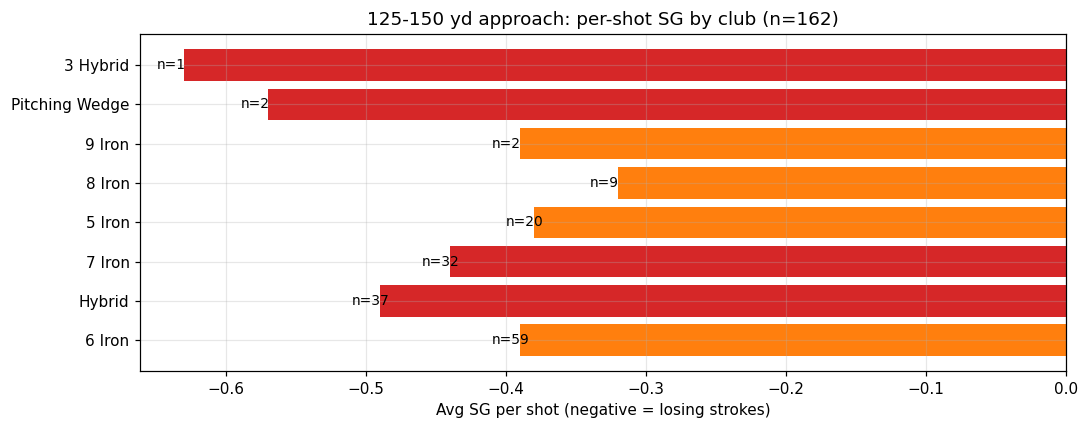

In [6]:
# Visualize the by-club breakdown.
fig, ax = plt.subplots(figsize=(10, 4))
bc = res["by_club"]
colors = ["#d62728" if v < -0.4 else "#ff7f0e" if v < -0.2 else "#2ca02c"
          for v in bc["avg_sg"]]
ax.barh(bc.index.astype(str), bc["avg_sg"], color=colors)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_title(f"125-150 yd approach: per-shot SG by club (n={res['n_total']})")
ax.set_xlabel("Avg SG per shot (negative = losing strokes)")
for i, (n, v) in enumerate(zip(bc["shots"], bc["avg_sg"])):
    ax.text(v - 0.02 if v < 0 else v + 0.02, i, f"n={n}",
            va="center", fontsize=9)
plt.tight_layout(); plt.show()

**How to read it.** The shot count next to each bar matters as much as the
SG figure — a brutally negative SG with n=3 might be noise; the same number
with n=50 is a real signal. Cross-reference against the by-lie and by-wind
tables to figure out whether it's the club, the situation, or the user.

## 2. Putt make-% by distance

First-putt-only (phantom 0-distance putts filtered out — Arccos logs those
when the ball is already at the hole). Buckets are inclusive of the lower
bound, exclusive of the upper. Tour benchmark from Broadie's published
PGA averages.

In [7]:
putts = dx.putt_make_by_distance(data)
putts

,band,attempts,makes,make_pct,tour_pct,gap_vs_tour
0,0-3 ft,2,1,50.0,99,-49.0
1,3-5 ft,22,12,54.5,88,-33.5
2,5-8 ft,40,10,25.0,58,-33.0
3,8-12 ft,53,9,17.0,33,-16.0
4,12-18 ft,88,16,18.2,17,1.2
5,18-25 ft,116,18,15.5,8,7.5
6,25-35 ft,119,18,15.1,4,11.1
7,35+ ft,151,15,9.9,2,7.9


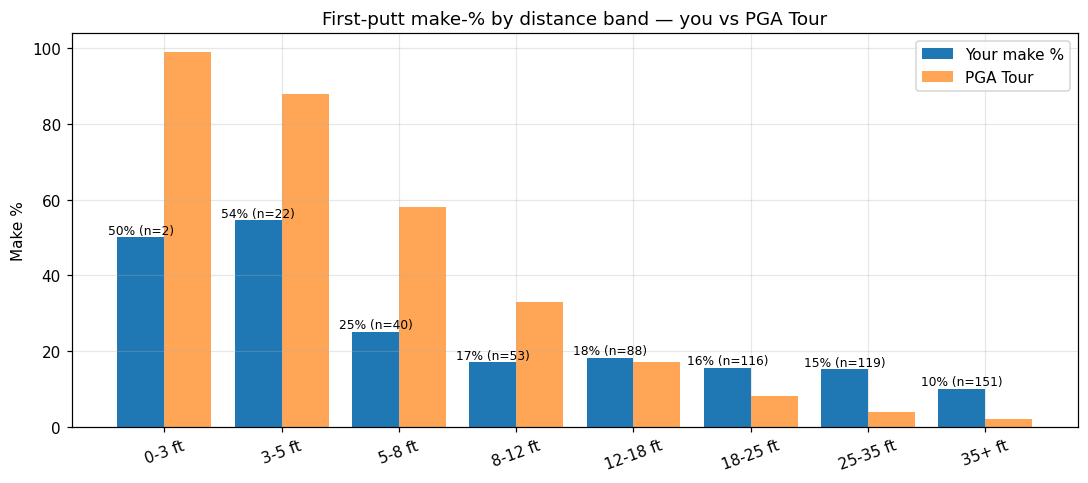

In [8]:
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(putts))
width = 0.4
ax.bar(x - width/2, putts["make_pct"], width, label="Your make %",
       color="#1f77b4")
ax.bar(x + width/2, putts["tour_pct"], width, label="PGA Tour",
       color="#ff7f0e", alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(putts["band"], rotation=20)
ax.set_ylabel("Make %")
ax.set_title("First-putt make-% by distance band — you vs PGA Tour")
ax.legend()
for i, (m, n) in enumerate(zip(putts["make_pct"], putts["attempts"])):
    ax.text(i - width/2, m + 1, f"{m:.0f}% (n={n})", ha="center", fontsize=8)
plt.tight_layout(); plt.show()

**Interpretation guide.** Where you're *below* Tour, that's a real practice
opportunity. Where you're *at or above* Tour (often the 18+ ft bands), don't
overinvest — Tour numbers in those bands are surprisingly low because making
a 25-ft putt is mostly luck even for the best players. Long-putt practice
is about avoiding 3-putts (lag distance control), not making them.

## 3. Lie-penalty matrix

Smart Distance per club split by lie (tee / fairway / rough / sand) from
`clubs.csv`. **Rough penalty** = fairway distance − rough distance, i.e.
how much carry you lose by missing the fairway. Negative penalty means
you actually got *more* distance from the rough (small samples or hot
rolls — interpret with caution).

In [9]:
lies = dx.lie_penalty_matrix(data)
lies

,display_club,From tee (yd),From fairway (yd),From rough (yd),From sand (yd),n shots,Rough penalty (yd)
3,3 Wood,223.1,192.9,202.9,201.5,22,-10.0
0,Driver,221.3,NaN,NaN,NaN,80,NaN
9,3 Hybrid,181.4,183.4,169.6,NaN,33,14.0
8,Hybrid,171.0,164.4,153.5,NaN,19,11.0
11,5 Iron,156.8,143.5,152.7,NaN,9,-9.0
19,6 Iron,143.6,140.5,138.1,NaN,20,2.0
23,7 Iron,132.9,125.6,137.9,NaN,12,-12.0
24,8 Iron,124.9,122.4,122.2,NaN,19,0.0
28,Pitching Wedge,120.4,102.4,99.4,NaN,5,3.0
27,9 Iron,113.8,108.6,107.4,91.9,9,1.0


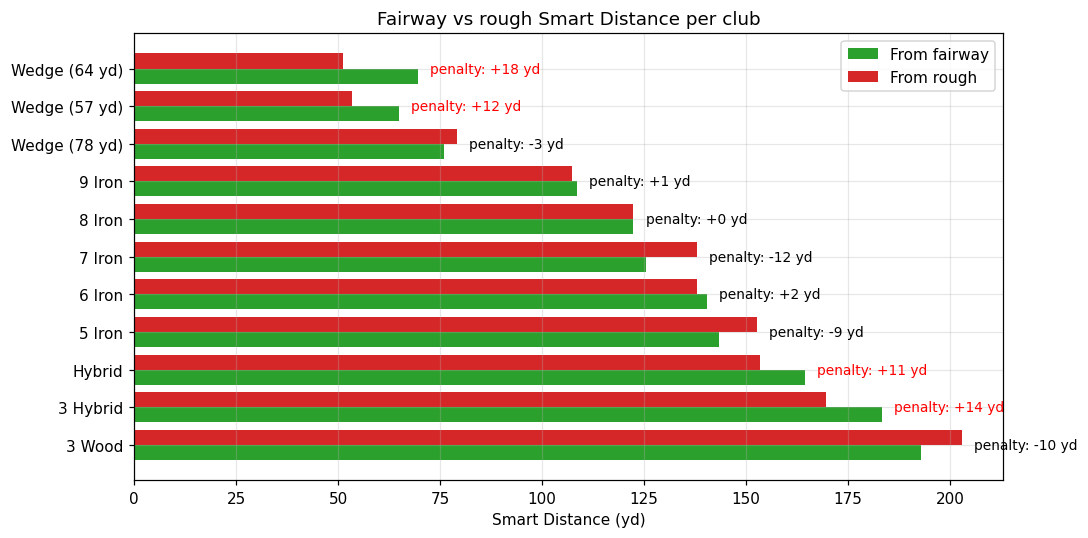

In [10]:
# Visualize fairway vs rough for clubs with enough data.
visible = lies[lies["n shots"] >= 8].dropna(subset=["From fairway (yd)", "From rough (yd)"])
fig, ax = plt.subplots(figsize=(10, 5))
y = np.arange(len(visible))
ax.barh(y - 0.2, visible["From fairway (yd)"], 0.4, label="From fairway",
        color="#2ca02c")
ax.barh(y + 0.2, visible["From rough (yd)"], 0.4, label="From rough",
        color="#d62728")
ax.set_yticks(y)
ax.set_yticklabels(visible["display_club"])
ax.set_xlabel("Smart Distance (yd)")
ax.set_title("Fairway vs rough Smart Distance per club")
ax.legend()
for i, (f, r) in enumerate(zip(visible["From fairway (yd)"], visible["From rough (yd)"])):
    pen = f - r
    color = "red" if pen > 5 else "black"
    ax.text(max(f, r) + 3, i, f"penalty: {pen:+.0f} yd",
            va="center", fontsize=9, color=color)
plt.tight_layout(); plt.show()

**Decision implication.** When a club's rough penalty is 10+ yards, missing
the fairway with that club is genuinely costly. On tight par-4s where you
can reach the green with a 3-wood from the fairway (penalty 0 yd) vs a
driver from the rough (penalty 10-20 yd), the conservative tee shot may
actually be the longer one to the green.

## 4. Twin Oaks hole-by-hole

Per-hole average score-to-par across all rounds at Twin Oaks GC (your most-
played course). `bleed_rank` 1 = worst hole, rank 18 = best. Use this to
target pre-round prep on the holes that hurt most and to be more
aggressive on the ones you score well on.

In [11]:
twin = dx.twin_oaks_hole_heatmap(data)
twin

,rounds,par,avg_score,avg_to_par,worst_to_par,best_to_par,bleed_rank
hole_id,,,,,,,
1,33,4,5.58,1.58,4,0,1
2,33,5,6.39,1.39,5,-1,5
3,33,3,4.45,1.45,3,0,3
4,33,4,5.45,1.45,4,-1,3
5,32,5,5.81,0.81,3,-1,14
6,32,4,5.31,1.31,4,-1,9
7,32,3,4.25,1.25,3,0,11
8,31,4,5.35,1.35,3,0,6
9,31,4,5.52,1.52,4,-1,2


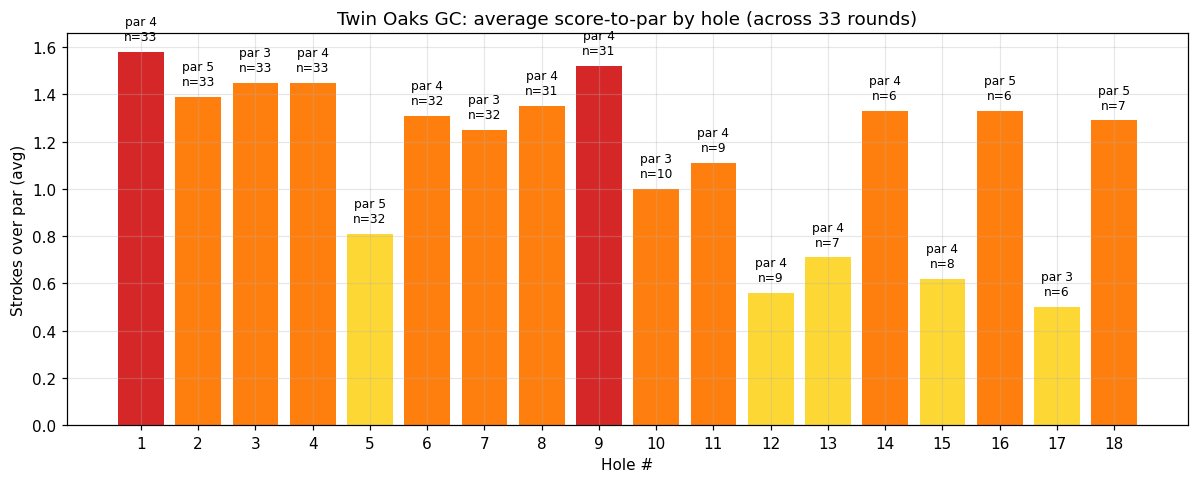

In [12]:
fig, ax = plt.subplots(figsize=(11, 4.5))
# Colour: red = bleed, green = score, scaled by par
colors = ["#d62728" if v >= 1.5 else
          "#ff7f0e" if v >= 1.0 else
          "#fdd835" if v >= 0.5 else "#2ca02c"
          for v in twin["avg_to_par"]]
ax.bar(twin.index.astype(str), twin["avg_to_par"], color=colors)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_title("Twin Oaks GC: average score-to-par by hole "
             f"(across {twin['rounds'].max()} rounds)")
ax.set_xlabel("Hole #")
ax.set_ylabel("Strokes over par (avg)")
for i, (par, n, v) in enumerate(zip(twin["par"], twin["rounds"], twin["avg_to_par"])):
    ax.text(i, v + 0.05, f"par {par}\nn={n}", ha="center", fontsize=8)
plt.tight_layout(); plt.show()

**Action plan.** Rank-1 holes (your worst) are where pre-round visualization
+ a clear course-management plan moves the needle. Rank-16-to-18 holes are
where you already score well — pin the strategy there, don't get cute.

For the bleed leaders specifically: check the matching by-club and by-lie
patterns from §1 — if hole 1 bleeds and most of your 1st-shot misses end in
rough on a tight fairway, your driver/3W choice is the lever, not your iron.